# **Projeto Churn**

> Preparação de dados, feature engineering e estruturação da base analítica para modelagem.



---



### **Índice**


1.  [**Sample:** Preparação e Separação da Base](#scrollTo=EZziXMbZT7Lx)
    *   [Filtrando a base Out of Time](#scrollTo=P3tXrb2PU7Bx)
    *   [Mapear features e variável resposta](#scrollTo=eZMMSJzb4J20)
    *   [Separando entre treino e teste](#scrollTo=rMxDPsgk4BLz)
    *   [Taxa variável resposta](#scrollTo=1FhYT4086nQA)
2.  [**Explore:** Análise Exploratória e Importância de Features](#scrollTo=EzMEeqj1C-z6)
    *   [Missings](#scrollTo=PlBDj0hdDQlt)
    *   [Análise Bivariada](#scrollTo=wn1b2Gk5EK28)
    *   [Importância das Features (Árvore de Decisão)](#scrollTo=v1iCqJzWIJyY)
3.  [**Modify:** Tratamento e Transformação das Features](#scrollTo=85dnmGVXNEky)


In [1]:
# Importar biblioteca:
import pandas as pd

# Criar df:
df = pd.read_csv('/content/abt_churn.csv')

df.head()

,dtRef,idUsuario,qtdeTransacoes,qtdeDias,mediaTransacoesDias,saldoPontos,qtdePontosPos,qtdePontosNeg,qtdeDiasUltimaTransacao,qtdeDiasPrimeiraTransacao,...,saldoPontosD28,qtdePontosPosD28,qtdePontosNegD28,propAvgQtdeTransacoes,propAvgQtdeDias,propAvgMediaTransacoesDias,propAvgSaldoPontos,propAvgQtdePontosPos,propAvgQtdePontosNeg,flagChurn
0,2024-06-01,000ff655-fa9f-4baa-a108-47f581ec52a1,266,27,9.851852,635,2635,-2000,1.0,89.0,...,151,151,0,3.889781,3.278281,2.135602,1.516314,4.101926,8.944444,1
1,2024-10-01,000ff655-fa9f-4baa-a108-47f581ec52a1,268,28,9.571429,686,2686,-2000,4.0,211.0,...,51,51,0,3.309865,2.567615,2.328737,1.288278,2.920954,5.167037,1
2,2024-04-01,000ff655-fa9f-4baa-a108-47f581ec52a1,188,11,17.090909,275,1275,-1000,3.0,28.0,...,275,1275,-1000,3.805468,1.820201,3.739048,0.798622,2.634551,7.162791,0
3,2024-05-01,000ff655-fa9f-4baa-a108-47f581ec52a1,262,24,10.916667,484,2484,-2000,2.0,58.0,...,107,1107,-1000,4.246216,3.255244,2.322640,1.275749,4.275765,9.922414,0
4,2024-08-01,001749bd-37b5-4b1e-8111-f9fbba90f530,1,1,1.000000,50,50,0,21.0,21.0,...,50,50,0,0.013317,0.103973,0.236635,0.104533,0.063302,0.000000,1


In [2]:
df.shape

(5496, 43)

# **1. Sample**
Trabalhar com uma amostra representativa, mas para também testar e validar o seu modelo.

* **Conceitos-chave:** Train/Test split, out of time, balanceamento, filtros.
* **Objetivo:** Garantir que tenha uma amostra que representa o mundo real.
* **Divisão de dados:** Utilizamos maior porcentagem para treino e menor para teste, por exemplo: **80% / 20%**.

> Ou seja, o primeiro passo é separar base de treino e base de teste.

* **Tratamento de Safras (Out of Time):**
  * Nesse caso, na nossa ABT tem safras (quando o dado foi registrado). Por margem de confiança, ordenamos a base e pegamos a parte mais recente e classificamos como uma base **out of time**. Treinamos o modelo no passado para prever o "futuro".
  * **Estabilidade:** Descobrir se o modelo é estável/possui robustez ao longo do tempo.
  * **Divisão final:**
    * Dados `-` dados out of time = separados em **80% / 20%**.
    * Os dados out of time serão usados para testar o modelo. Nos dados que não são out of time, eles continuam embaralhados nos 20 e 80.

In [3]:
# Verificamos as datas:

df['dtRef'].sort_values().unique()

array(['2024-03-01', '2024-04-01', '2024-05-01', '2024-06-01',
       '2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01',
       '2024-11-01', '2024-12-01', '2025-01-01', '2025-02-01',
       '2025-03-01', '2025-04-01'], dtype=object)

In [4]:
# Verificamos a quantidade de registros por safra:

df['dtRef'].value_counts().sort_index()

# Base "Out of Time" será 2025/04/01

,count
dtRef,
2024-03-01,665
2024-04-01,528
2024-05-01,542
2024-06-01,426
2024-07-01,422
2024-08-01,415
2024-09-01,371
2024-10-01,349
2024-11-01,258


### **1. Filtrando a base Out of Time:**

In [5]:
oot = df[df['dtRef'] == df['dtRef'].max()].copy()
oot

,dtRef,idUsuario,qtdeTransacoes,qtdeDias,mediaTransacoesDias,saldoPontos,qtdePontosPos,qtdePontosNeg,qtdeDiasUltimaTransacao,qtdeDiasPrimeiraTransacao,...,saldoPontosD28,qtdePontosPosD28,qtdePontosNegD28,propAvgQtdeTransacoes,propAvgQtdeDias,propAvgMediaTransacoesDias,propAvgSaldoPontos,propAvgQtdePontosPos,propAvgQtdePontosNeg,flagChurn
8,2025-04-01,0033b737-8235-4c0f-9801-dc4ca185af00,445,25,17.800000,2066,2066,0,6.0,197.0,...,976,976,0,5.463477,2.123061,4.501847,3.989389,2.191048,0.000000,1
21,2025-04-01,0122142b-464c-414a-9aad-e901f492a1a3,23,4,5.750000,121,121,0,7.0,81.0,...,2,2,0,0.282382,0.339690,1.454248,0.233648,0.128324,0.000000,1
53,2025-04-01,0287cd05-1efe-4ad9-b235-ea17e5f8ef9c,303,45,6.733333,3248,3498,-250,1.0,351.0,...,615,615,0,3.720076,3.821510,1.702946,6.271798,3.709722,0.588161,0
61,2025-04-01,02bfd4d9-4dd6-44e5-88b8-2cc08caf3267,338,89,3.797753,3643,7143,-3500,4.0,333.0,...,265,265,0,4.149787,7.558098,0.960500,7.034532,7.575342,8.234250,0
74,2025-04-01,02ebaed5-c07a-4bdd-bb7b-5334d5b25b39,245,51,4.803922,3813,3813,0,18.0,246.0,...,50,50,0,3.007982,4.331045,1.214973,7.362797,4.043788,0.000000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5460,2025-04-01,fd511f05-5cd3-430f-8cb5-179ce740c6b4,98,28,3.500000,816,1816,-1000,1.0,71.0,...,-11,989,-1000,1.203193,2.377829,0.885195,1.575673,1.925916,2.352643,0
5468,2025-04-01,fd60694f-cc3e-47a0-98de-cf7bcfbcd2db,59,23,2.565217,763,763,0,25.0,203.0,...,1,1,0,0.724371,1.953216,0.648776,1.473332,0.809182,0.000000,0
5470,2025-04-01,fdac1c1e-bd14-4f14-8fbd-e4265e3e7ac7,45,20,2.250000,1174,1174,0,8.0,50.0,...,620,620,0,0.552486,1.698449,0.569054,2.266961,1.245058,0.000000,1
5473,2025-04-01,fe391f8e-c2eb-4bd9-b8a5-e284151deb6a,3,3,1.000000,150,150,0,18.0,49.0,...,50,50,0,0.036832,0.254767,0.252913,0.289646,0.159079,0.000000,1


### **2. Separando a base:**

In [6]:
 # Base de treino:

df_train = df[df['dtRef']<df['dtRef'].max()].copy()
df_train.head()

,dtRef,idUsuario,qtdeTransacoes,qtdeDias,mediaTransacoesDias,saldoPontos,qtdePontosPos,qtdePontosNeg,qtdeDiasUltimaTransacao,qtdeDiasPrimeiraTransacao,...,saldoPontosD28,qtdePontosPosD28,qtdePontosNegD28,propAvgQtdeTransacoes,propAvgQtdeDias,propAvgMediaTransacoesDias,propAvgSaldoPontos,propAvgQtdePontosPos,propAvgQtdePontosNeg,flagChurn
0,2024-06-01,000ff655-fa9f-4baa-a108-47f581ec52a1,266,27,9.851852,635,2635,-2000,1.0,89.0,...,151,151,0,3.889781,3.278281,2.135602,1.516314,4.101926,8.944444,1
1,2024-10-01,000ff655-fa9f-4baa-a108-47f581ec52a1,268,28,9.571429,686,2686,-2000,4.0,211.0,...,51,51,0,3.309865,2.567615,2.328737,1.288278,2.920954,5.167037,1
2,2024-04-01,000ff655-fa9f-4baa-a108-47f581ec52a1,188,11,17.090909,275,1275,-1000,3.0,28.0,...,275,1275,-1000,3.805468,1.820201,3.739048,0.798622,2.634551,7.162791,0
3,2024-05-01,000ff655-fa9f-4baa-a108-47f581ec52a1,262,24,10.916667,484,2484,-2000,2.0,58.0,...,107,1107,-1000,4.246216,3.255244,2.322640,1.275749,4.275765,9.922414,0
4,2024-08-01,001749bd-37b5-4b1e-8111-f9fbba90f530,1,1,1.000000,50,50,0,21.0,21.0,...,50,50,0,0.013317,0.103973,0.236635,0.104533,0.063302,0.000000,1


In [7]:
df_train['dtRef'].sort_values().unique()

array(['2024-03-01', '2024-04-01', '2024-05-01', '2024-06-01',
       '2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01',
       '2024-11-01', '2024-12-01', '2025-01-01', '2025-02-01',
       '2025-03-01'], dtype=object)

In [8]:
df_train.shape

(5193, 43)

### **Separando entre treino e teste:**

 **Mapear features e variável resposta:**

In [9]:
df_train.head()

# Pegar qtd transações até a penúltima (antes da target)

features = df_train.columns[2:-1]
target = 'flagChurn'

# Definir X, y:

X, y = df_train[features], df_train[target]

**Separação:**

In [10]:
# Split

from sklearn import model_selection

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y,
                                                                    random_state=42,
                                                                    test_size=0.2,
                                                                    stratify=y) # Passando dois objetos para a função, ambos devem possuir a mesma quantidade de linhas
                                                                                   # Dividindo entre treino e teste para cada objeto passado
                                                                                   # Tamanho da base de teste: 20%
                                                                                   # Estratificação: antes de fazer a amostragem separamos 0's e 1's, após teremos 20% e 80% de cada,
                                                                                   # garantindo a taxa próxima (Atenção ao custo, aqui será simples por temos 2 variações)

                                                                                   # Temas importantes: balanceamento: quando será necessário?

**Taxa variável resposta:**

In [11]:
print(f'Taxa variável resposta (treino):', y_train.mean())
print(f'Taxa variável resposta (teste):', y_test.mean())
print(f'Taxa variável resposta (verdadeira):', y.mean())

# As amostras são parecidas?
# Posso confiar nas amostras? Foi separada de forma representativa?

# Não é um evento raro.
# - Evento Raro: Taxa extremamente alta ou extremamente baixa

Taxa variável resposta (treino): 0.46894559460760715
Taxa variável resposta (teste): 0.4687199230028874
Taxa variável resposta (verdadeira): 0.4689004429039091


# **2. Explore:**
*Geralmente o criador da base ABT deve ser o mesmo criador do modelo, logo, o EDA não necessariamente levará muito tempo para ser realizado nessa etapa especificamente.*

In [12]:
# Missings:
X_train.isna().sum().sort_values(ascending=False)

,0
qtdeTransacoes,0
qtdeDias,0
mediaTransacoesDias,0
saldoPontos,0
qtdePontosPos,0
qtdePontosNeg,0
qtdeDiasUltimaTransacao,0
qtdeDiasPrimeiraTransacao,0
qtdSkuDistintos,0
qtdeChatMessage,0


In [13]:
# Análise Bivariada
# Quais as features que nos ajudam a prever a target?

df_analise = X_train.copy() # Copy para copiar e não transformar df_analise em ponteiro
df_analise[target] = y_train

sumario = df_analise.groupby(by=target).agg(['mean','median']).T

sumario['diff_abs'] = sumario[0] - sumario[1]
sumario['diff_rel'] = sumario[0] / sumario[1]

pd.set_option('display.max_rows', None)
sumario.sort_values(by=['diff_rel'], ascending=False)

# Ponto importante: essa classificação serve para variáveis numéricas

,flagChurn,0,1,diff_abs,diff_rel
qtdeDiasD7,median,1.000000,0.000000,1.000000,inf
qtdeTransacoesD7,median,3.000000,0.000000,3.000000,inf
saldoPontosD7,median,50.000000,0.000000,50.000000,inf
qtdePontosPosD7,median,52.000000,0.000000,52.000000,inf
qtdePontosPosD14,median,107.000000,1.000000,106.000000,107.000000
saldoPontosD14,median,100.000000,1.000000,99.000000,100.000000
qtdePontosNegD14,mean,-136.903445,-7.007187,-129.896258,19.537576
qtdePontosNegD7,mean,-67.429737,-3.644764,-63.784973,18.500441
qtdePontosNegD28,mean,-300.072076,-21.765914,-278.306162,13.786330
qtdeRLover,mean,0.067090,0.006160,0.060930,10.890904


[Text(0.48660714285714285, 0.9166666666666666, 'qtdeDiasD14 <= 2.5\ngini = 0.498\nsamples = 4154\nvalue = [2206, 1948]\nclass = 0'),
 Text(0.22767857142857142, 0.75, 'propAvgQtdeDias <= 0.546\ngini = 0.471\nsamples = 2900\nvalue = [1098.0, 1802.0]\nclass = 1'),
 Text(0.35714285714285715, 0.8333333333333333, 'True  '),
 Text(0.09821428571428571, 0.5833333333333334, 'qtdePontosPosD7 <= 1.5\ngini = 0.4\nsamples = 1578\nvalue = [436, 1142]\nclass = 1'),
 Text(0.05357142857142857, 0.4166666666666667, 'qtdePontosPos <= 582.0\ngini = 0.34\nsamples = 1104\nvalue = [240, 864]\nclass = 1'),
 Text(0.03571428571428571, 0.25, 'propAvgQtdeDias <= 0.151\ngini = 0.337\nsamples = 1100\nvalue = [236, 864]\nclass = 1'),
 Text(0.017857142857142856, 0.08333333333333333, 'gini = 0.252\nsamples = 325\nvalue = [48.0, 277.0]\nclass = 1'),
 Text(0.05357142857142857, 0.08333333333333333, 'gini = 0.367\nsamples = 775\nvalue = [188, 587]\nclass = 1'),
 Text(0.07142857142857142, 0.25, 'gini = 0.0\nsamples = 4\nvalu

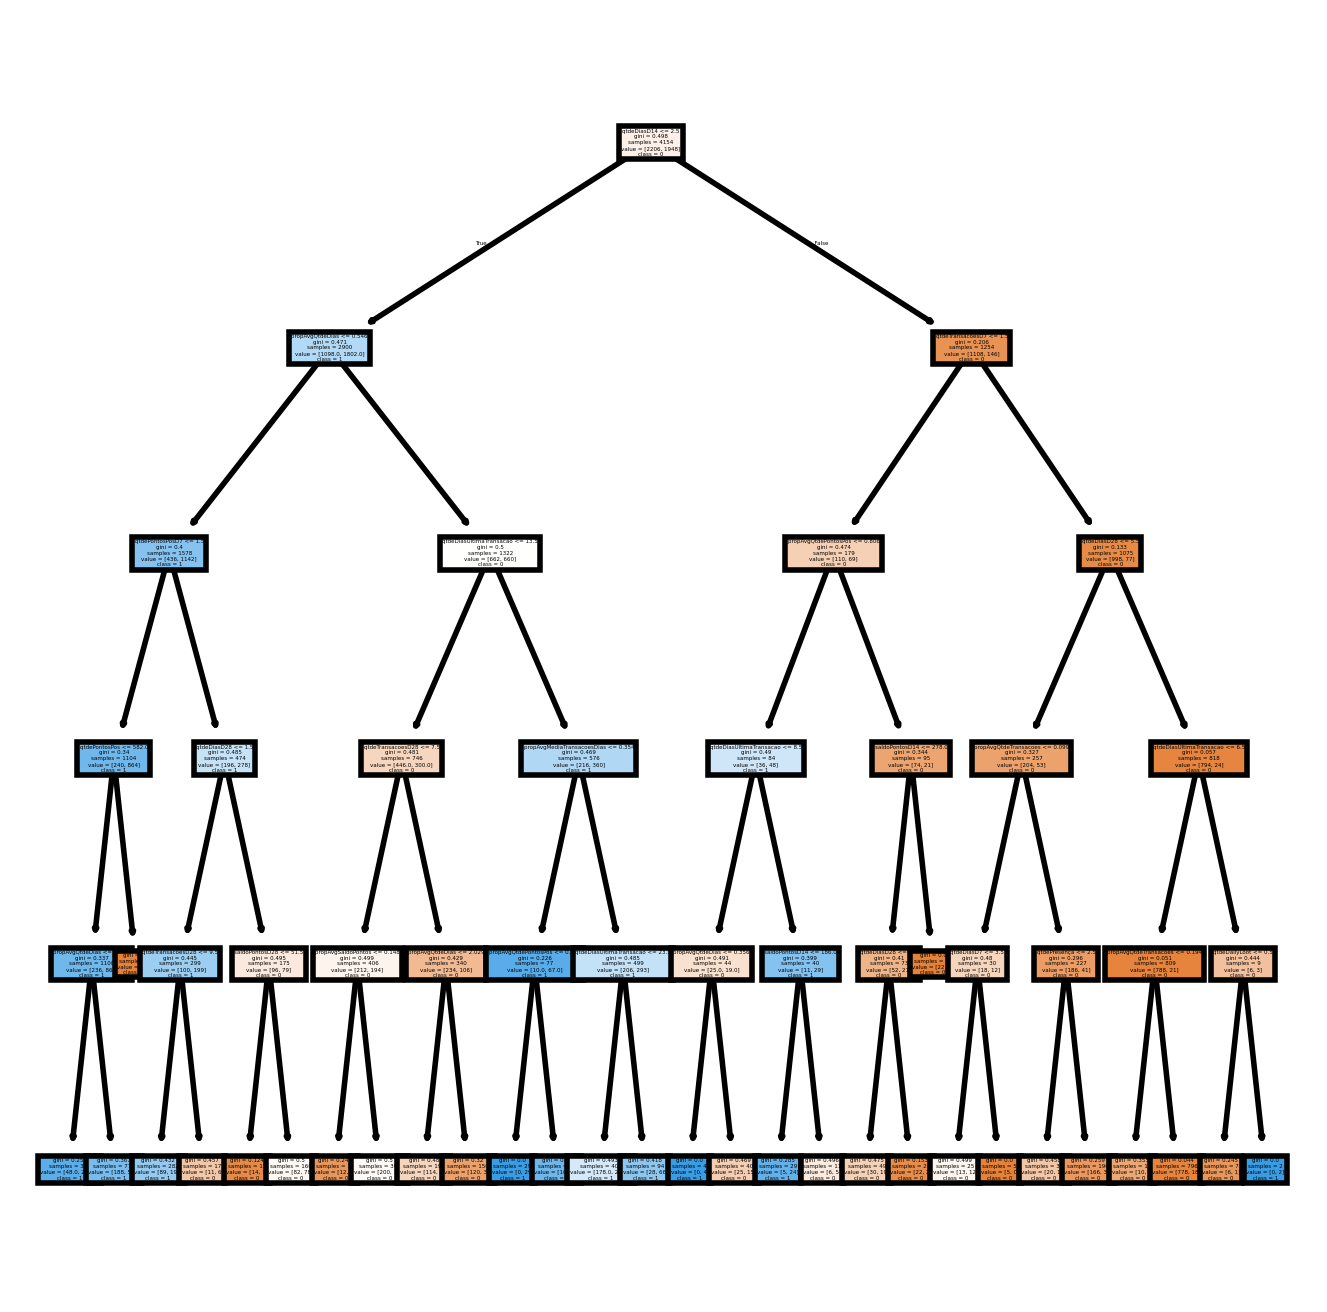

In [14]:
# Árvore para explorar:

from sklearn import tree
import matplotlib.pyplot as plt


arvore = tree.DecisionTreeClassifier(random_state=42, max_depth=5)
arvore.fit(X_train, y_train)

plt.figure(dpi=400, figsize=[4,4])
tree.plot_tree(arvore, feature_names=X_train.columns,
               class_names=[str(i) for i in arvore.classes_], # para class names como numero
               filled=True)

In [15]:
X_train.shape

(4154, 40)

In [16]:
feature_importance = (pd.Series(arvore.feature_importances_, index=X_train.columns).sort_values(ascending=False).reset_index())
feature_importance['acum']= feature_importance[0].cumsum()

# Com acima de 1% de importância e importância
# ,acumulada menor do que 96%
feature_importance[feature_importance[0] > 0.01]
feature_importance[feature_importance['acum'] < 0.96]

,index,0,acum
0,qtdeDiasD14,0.620636,0.620636
1,propAvgQtdeDias,0.119771,0.740407
2,qtdeDiasUltimaTransacao,0.056484,0.796891
3,qtdeTransacoesD7,0.042025,0.838916
4,qtdePontosPosD7,0.035461,0.874377
5,qtdeDiasD28,0.035236,0.909613
6,qtdeTransacoesD28,0.019086,0.928699
7,propAvgQtdePontosPos,0.017399,0.946098


In [17]:
best_features = feature_importance[feature_importance['acum']<0.96]['index'].tolist()
best_features

['qtdeDiasD14',
 'propAvgQtdeDias',
 'qtdeDiasUltimaTransacao',
 'qtdeTransacoesD7',
 'qtdePontosPosD7',
 'qtdeDiasD28',
 'qtdeTransacoesD28',
 'propAvgQtdePontosPos']

# **3. Modify:**
*Padronização (todas as varíaveis na mesma escala), inputação de missing, bining e combinação.*



> **Exemplo:** inputação de missing, se tivermos uma coluna de idade com muitos missing values, poderíamos identificar a idade provável utilizando as outras colunas. É extremamente importante entender quando, como e se faz sentido realizar a inputação de missings.



In [18]:
# Calcular taxa de resposta pra cada nível (variável categoria) e criar uma nova coluna: Mean Encoder
# é possível criar novas varíaveis, multplicar, combinar etc

### What is Binning (Discretization)?

**Binning**, also known as **discretization**, is a data preprocessing technique used to transform continuous numerical variables into discrete, categorical ones. Instead of having a wide range of values, binning groups these values into a smaller number of 'bins' or intervals.

*   **Example:** Instead of an exact age (e.g., 25, 31, 48), you might group ages into bins like 'Young' (18-30), 'Middle-Aged' (31-50), and 'Senior' (51+).
*   **Purpose:**
    *   **Simplify Data:** Makes complex relationships easier to understand.
    *   **Handle Outliers:** Can make models less sensitive to extreme values.
    *   **Improve Model Performance:** Some models (e.g., those that assume categorical inputs or have difficulty with continuous non-linear relationships) can perform better with binned data.
    *   **Interpretability:** Categorical data is often more intuitive to interpret.


In [19]:
# Biblioteca Feature-engine

!pip install feature-engine


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 16.1 MB/s eta 0:00:00


In [20]:
from feature_engine import discretisation

In [21]:
tree_d = discretisation.DecisionTreeDiscretiser(variables=best_features,
                                                regression=False,
                                                cv=3) # nossa variável é de classificação

In [22]:
X_train.head()

,qtdeTransacoes,qtdeDias,mediaTransacoesDias,saldoPontos,qtdePontosPos,qtdePontosNeg,qtdeDiasUltimaTransacao,qtdeDiasPrimeiraTransacao,qtdSkuDistintos,qtdeChatMessage,...,qtdeDiasD28,saldoPontosD28,qtdePontosPosD28,qtdePontosNegD28,propAvgQtdeTransacoes,propAvgQtdeDias,propAvgMediaTransacoesDias,propAvgSaldoPontos,propAvgQtdePontosPos,propAvgQtdePontosNeg
1283,3,3,1.000000,150,150,0,10.0,12.0,1,0,...,3,150,150,0,0.038607,0.289318,0.241858,0.295608,0.174560,0.0
3015,12,5,2.400000,257,257,0,6.0,25.0,2,7,...,5,257,257,0,0.154430,0.482197,0.580460,0.506474,0.299079,0.0
3773,47,27,1.740741,1969,1969,0,6.0,98.0,4,19,...,5,757,757,0,0.640393,2.994404,0.386389,4.361164,2.763287,0.0
1823,4,1,4.000000,53,53,0,7.0,7.0,2,3,...,1,53,53,0,0.080967,0.165473,0.875096,0.153916,0.109515,0.0
4577,32,7,4.571429,228,228,0,15.0,107.0,2,28,...,1,1,1,0,0.395953,0.607107,1.145970,0.439370,0.242994,0.0


In [23]:
# O ajuste do DecisionTreeDiscretiser foi movido para a célula q14sT_YXaWgA para garantir a ordem de execução.

# **4. Model:**
*Aplicar os modelos.*

# **1. Regressão Logística**

####  **Exemplo de aplicação realizando a discretização (Binning):**

In [24]:
from sklearn import linear_model
reg = linear_model.LogisticRegression(penalty=None, random_state=42, max_iter=10000000)

In [25]:
from feature_engine import encoding

---
#### **Resumo da Etapa "Modify"**

Nesta etapa, focamos na transformação das features para prepará-las para a modelagem, utilizando duas técnicas principais de *Feature Engineering*:

1.  **Discretização (Binning) com `DecisionTreeDiscretiser`:**
    *   Primeiro, instalamos a biblioteca `feature_engine` para nos auxiliar. Em seguida, utilizamos o `DecisionTreeDiscretiser` para transformar as `best_features` (as características mais importantes identificadas na etapa anterior) de variáveis contínuas em categorias discretas (bins).
    *   Isso foi feito 'ensinando' o discretizador com os dados de treino (`X_train[best_features]` e `y_train`) e depois aplicando essa transformação aos conjuntos de treino (`X_train_transformed`), teste (`X_test_transformed`) e Out-of-Time (`X_oot_transformed`). Essa técnica ajuda a simplificar os dados e melhorar a performance de alguns modelos.

2.  **One-Hot Encoding com `OneHotEncoder`:**
    *   Após a discretização, as variáveis transformadas ainda podem estar em um formato que alguns modelos (como a Regressão Logística) interpretam melhor como categorias separadas. Para isso, aplicamos o `OneHotEncoder` da `feature_engine`.
    *   Este encoder transformou cada categoria discreta criada na etapa anterior em uma nova coluna binária (0 ou 1), onde '1' indica a presença daquela categoria e '0' a ausência. Isso foi aplicado aos dados de treino transformados (`X_train_transformed`), e o mesmo processo seria feito para os conjuntos de teste e Out-of-Time para garantir consistência antes da modelagem.

### **Maneiras mais facéis de modificar os dados:**

- Nas células anteriores aplicavámos primeiro a discretização, após o one hot e aí sim no modelo. Porém, há um meio de criar um pipeline encapsulando todos aqueles passos, tendo: **X_train = discretização -> onehot -> modelo.**

In [26]:
## Nó de Discretização:
tree_d = discretisation.DecisionTreeDiscretiser(variables=best_features,
                                                regression=False,
                                                cv=3) # nossa variável é de classificação
# -----------------------------------------------------------------------------------------------------------
## Nó do One Hot Encoding:
onehot = encoding.OneHotEncoder(variables=best_features, ignore_format=True)
# -----------------------------------------------------------------------------------------------------------
## Nó do modelo:
reg = linear_model.LogisticRegression(penalty=None, random_state=42, max_iter=10000000)

# **Pipeline**

In [27]:
from sklearn import pipeline

model_pipeline = pipeline.Pipeline(
    steps=[
        ('Discretizar', tree_d),
        ('One Hot Encoding', onehot),
        ('Model', reg)
    ]
)

model_pipeline.fit(X_train[best_features], y_train)

Pipeline(steps=[('Discretizar',
                 DecisionTreeDiscretiser(regression=False,
                                         variables=['qtdeDiasD14',
                                                    'propAvgQtdeDias',
                                                    'qtdeDiasUltimaTransacao',
                                                    'qtdeTransacoesD7',
                                                    'qtdePontosPosD7',
                                                    'qtdeDiasD28',
                                                    'qtdeTransacoesD28',
                                                    'propAvgQtdePontosPos'])),
                ('One Hot Encoding',
                 OneHotEncoder(ignore_format=True,
                               variables=['qtdeDiasD14', 'propAvgQtdeDias',
                                          'qtdeDiasUltimaTransacao',
                                          'qtdeTransacoesD7', 'qtdePontosPosD7',
                                          'qtdeDiasD28', 'qtdeTransacoesD28',
                                          'propAvgQtdePontosPos'])),
                ('Model',
                 LogisticRegression(max_iter=10000000, penalty=None,
                                    random_state=42))])

In [28]:
# Realizar a predição com o Pipeline:
from sklearn import metrics
# Treino:
y_train_predict = model_pipeline.predict(X_train[best_features])
y_train_proba = model_pipeline.predict_proba(X_train[best_features])[:,1]
acc_train = metrics.accuracy_score(y_train, y_train_predict)
auc_train = metrics.roc_auc_score(y_train, y_train_proba)
print(f'Acurácia (Treino):', acc_train)
print(f'AUC (Treino):', auc_train)
# Teste:
y_test_predict = model_pipeline.predict(X_test[best_features])
y_test_proba = model_pipeline.predict_proba(X_test[best_features])[:,1]
acc_test = metrics.accuracy_score(y_test, y_test_predict)
auc_test = metrics.roc_auc_score(y_test, y_test_proba)
print(f'Acurácia (Teste):', acc_test)
print(f'AUC (Teste):', auc_test)
#  Out of Time:
y_oot_predict = model_pipeline.predict(oot[best_features])
y_oot_proba = model_pipeline.predict_proba(oot[best_features])[:,1]
acc_oot = metrics.accuracy_score(oot[target], y_oot_predict)
auc_oot = metrics.roc_auc_score(oot[target], y_oot_proba)
print(f'Acurácia (OOT):', acc_oot)
print(f'AUC (OOT):', auc_oot)

Acurácia (Treino): 0.7409725565719788
AUC (Treino): 0.8285823524045863
Acurácia (Teste): 0.7516843118383061
AUC (Teste): 0.8317077344284736
Acurácia (OOT): 0.7623762376237624
AUC (OOT): 0.8297821350762528


# **Gráficos**

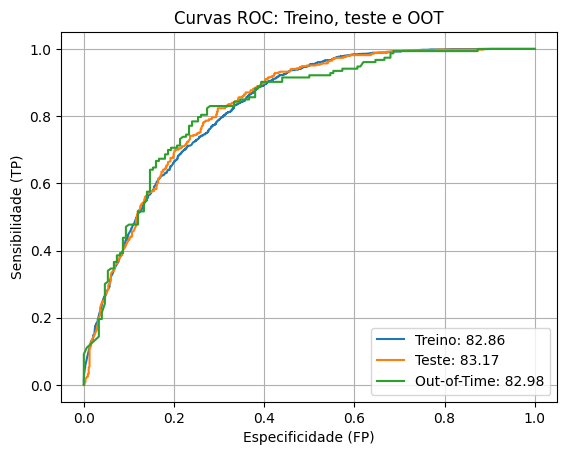

In [29]:
roc_train = metrics.roc_curve(y_train, y_train_proba)
roc_test = metrics.roc_curve(y_test, y_test_proba)
roc_oot = metrics.roc_curve(oot[target], y_oot_proba)


plt.plot(roc_train[0], roc_train[1])
plt.plot(roc_test[0], roc_test[1])
plt.plot(roc_oot[0], roc_oot[1])
plt.grid(True)
plt.title('Curvas ROC: Treino, teste e OOT')
plt.xlabel('Especificidade (FP)')
plt.ylabel('Sensibilidade (TP)')
plt.legend([
        f'Treino: {100*auc_train:.2f}',
        f'Teste: {100*auc_test:.2f}',
        f'Out-of-Time: {100*auc_oot:.2f}'
        ])

# **2. Naive Bayes**

In [30]:
from sklearn import naive_bayes

model = naive_bayes.BernoulliNB() # Todas as variáveis são com hot encoding


model_pipeline = pipeline.Pipeline(
    steps=[
        ('Discretizar', tree_d),
        ('One Hot Encoding', onehot),
        ('Model', model)
    ]
)

model_pipeline.fit(X_train[best_features], y_train)

Pipeline(steps=[('Discretizar',
                 DecisionTreeDiscretiser(regression=False,
                                         variables=['qtdeDiasD14',
                                                    'propAvgQtdeDias',
                                                    'qtdeDiasUltimaTransacao',
                                                    'qtdeTransacoesD7',
                                                    'qtdePontosPosD7',
                                                    'qtdeDiasD28',
                                                    'qtdeTransacoesD28',
                                                    'propAvgQtdePontosPos'])),
                ('One Hot Encoding',
                 OneHotEncoder(ignore_format=True,
                               variables=['qtdeDiasD14', 'propAvgQtdeDias',
                                          'qtdeDiasUltimaTransacao',
                                          'qtdeTransacoesD7', 'qtdePontosPosD7',
                                          'qtdeDiasD28', 'qtdeTransacoesD28',
                                          'propAvgQtdePontosPos'])),
                ('Model', BernoulliNB())])

Acurácia (Treino): 0.7404910929224844
AUC (Treino): 0.8201851958723735
Acurácia (Teste): 0.7526467757459095
AUC (Teste): 0.8294423116983601
Acurácia (OOT): 0.768976897689769
AUC (OOT): 0.8291285403050108


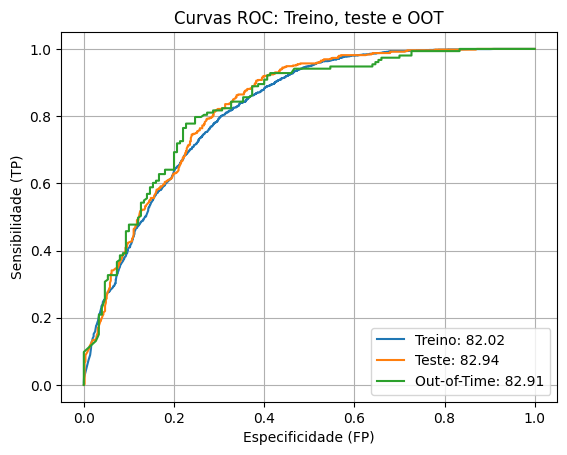

In [31]:
##############################################################################
# PREDIÇÃO
##############################################################################

# Treino:
y_train_predict = model_pipeline.predict(X_train[best_features])
y_train_proba = model_pipeline.predict_proba(X_train[best_features])[:,1]
acc_train = metrics.accuracy_score(y_train, y_train_predict)
auc_train = metrics.roc_auc_score(y_train, y_train_proba)
print(f'Acurácia (Treino):', acc_train)
print(f'AUC (Treino):', auc_train)
# Teste:
y_test_predict = model_pipeline.predict(X_test[best_features])
y_test_proba = model_pipeline.predict_proba(X_test[best_features])[:,1]
acc_test = metrics.accuracy_score(y_test, y_test_predict)
auc_test = metrics.roc_auc_score(y_test, y_test_proba)
print(f'Acurácia (Teste):', acc_test)
print(f'AUC (Teste):', auc_test)
#  Out of Time:
y_oot_predict = model_pipeline.predict(oot[best_features])
y_oot_proba = model_pipeline.predict_proba(oot[best_features])[:,1]
acc_oot = metrics.accuracy_score(oot[target], y_oot_predict)
auc_oot = metrics.roc_auc_score(oot[target], y_oot_proba)
print(f'Acurácia (OOT):', acc_oot)
print(f'AUC (OOT):', auc_oot)

##############################################################################
# CURVA ROC
##############################################################################

roc_train = metrics.roc_curve(y_train, y_train_proba)
roc_test = metrics.roc_curve(y_test, y_test_proba)
roc_oot = metrics.roc_curve(oot[target], y_oot_proba)


plt.plot(roc_train[0], roc_train[1])
plt.plot(roc_test[0], roc_test[1])
plt.plot(roc_oot[0], roc_oot[1])
plt.grid(True)
plt.title('Curvas ROC: Treino, teste e OOT')
plt.xlabel('Especificidade (FP)')
plt.ylabel('Sensibilidade (TP)')
plt.legend([
        f'Treino: {100*auc_train:.2f}',
        f'Teste: {100*auc_test:.2f}',
        f'Out-of-Time: {100*auc_oot:.2f}'
        ])

# **3. Random Forest**

> Diversas árvores de decisão com amostras aleatórias.



In [32]:
from sklearn import ensemble
model = ensemble.RandomForestClassifier(random_state=42,
                                        min_samples_leaf=20,
                                        n_jobs=-1,
                                        n_estimators=1000) # Realizar de forma paralela, pois são independentes, -1: todos núcleos
                                                           # Quantas árvores quer gerar

model_pipeline = pipeline.Pipeline(
    steps=[
        ('Discretizar', tree_d),
        ('One Hot Encoding', onehot),
        ('Model', model)
    ]
)


model_pipeline.fit(X_train[best_features], y_train)

Pipeline(steps=[('Discretizar',
                 DecisionTreeDiscretiser(regression=False,
                                         variables=['qtdeDiasD14',
                                                    'propAvgQtdeDias',
                                                    'qtdeDiasUltimaTransacao',
                                                    'qtdeTransacoesD7',
                                                    'qtdePontosPosD7',
                                                    'qtdeDiasD28',
                                                    'qtdeTransacoesD28',
                                                    'propAvgQtdePontosPos'])),
                ('One Hot Encoding',
                 OneHotEncoder(ignore_format=True,
                               variables=['qtdeDiasD14', 'propAvgQtdeDias',
                                          'qtdeDiasUltimaTransacao',
                                          'qtdeTransacoesD7', 'qtdePontosPosD7',
                                          'qtdeDiasD28', 'qtdeTransacoesD28',
                                          'propAvgQtdePontosPos'])),
                ('Model',
                 RandomForestClassifier(min_samples_leaf=20, n_estimators=1000,
                                        n_jobs=-1, random_state=42))])

Acurácia (Treino): 0.7477130476649013
AUC (Treino): 0.8343224843203434
Acurácia (Teste): 0.7613089509143407
AUC (Teste): 0.8325223938338838
Acurácia (OOT): 0.7722772277227723
AUC (OOT): 0.8293464052287581
#------------------------------------------------------


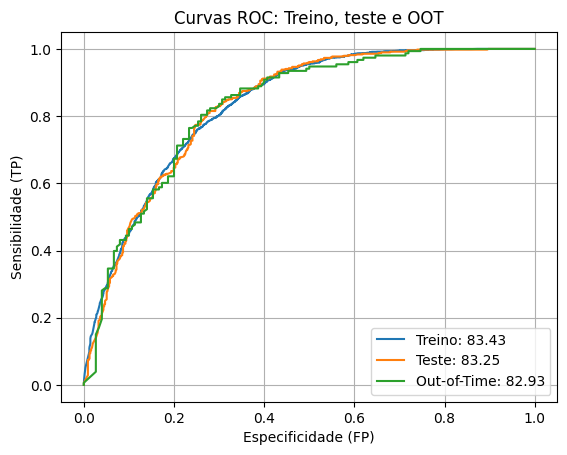

In [33]:
##############################################################################
# PREDIÇÃO
##############################################################################

y_train_predict = model_pipeline.predict(X_train[best_features])
y_train_proba = model_pipeline.predict_proba(X_train[best_features])[:,1]
acc_train = metrics.accuracy_score(y_train, y_train_predict)
auc_train = metrics.roc_auc_score(y_train, y_train_proba)
print(f'Acurácia (Treino):', acc_train)
print(f'AUC (Treino):', auc_train)
y_test_predict = model_pipeline.predict(X_test[best_features])
y_test_proba = model_pipeline.predict_proba(X_test[best_features])[:,1]
acc_test = metrics.accuracy_score(y_test, y_test_predict)
auc_test = metrics.roc_auc_score(y_test, y_test_proba)
print(f'Acurácia (Teste):', acc_test)
print(f'AUC (Teste):', auc_test)
y_oot_predict = model_pipeline.predict(oot[best_features])
y_oot_proba = model_pipeline.predict_proba(oot[best_features])[:,1]
acc_oot = metrics.accuracy_score(oot[target], y_oot_predict)
auc_oot = metrics.roc_auc_score(oot[target], y_oot_proba)
print(f'Acurácia (OOT):', acc_oot)
print(f'AUC (OOT):', auc_oot)

print('#------------------------------------------------------')
##############################################################################
# CURVA ROC
##############################################################################

roc_train = metrics.roc_curve(y_train, y_train_proba)
roc_test = metrics.roc_curve(y_test, y_test_proba)
roc_oot = metrics.roc_curve(oot[target], y_oot_proba)


plt.plot(roc_train[0], roc_train[1])
plt.plot(roc_test[0], roc_test[1])
plt.plot(roc_oot[0], roc_oot[1])
plt.grid(True)
plt.title('Curvas ROC: Treino, teste e OOT')
plt.xlabel('Especificidade (FP)')
plt.ylabel('Sensibilidade (TP)')
plt.legend([
        f'Treino: {100*auc_train:.2f}',
        f'Teste: {100*auc_test:.2f}',
        f'Out-of-Time: {100*auc_oot:.2f}'
        ])

- Criação das variáveis é muito importante para a performance do seu modelo.


# **Tuning**

*   Qual a melhor configuração para cada modelo?

Com random forest:



In [53]:
## Nó de Discretização:
tree_d = discretisation.DecisionTreeDiscretiser(variables=best_features,
                                                regression=False,
                                                cv=3) # nossa variável é de classificação
# -----------------------------------------------------------------------------------------------------------
## Nó do One Hot Encoding:
onehot = encoding.OneHotEncoder(variables=best_features, ignore_format=True)
# -----------------------------------------------------------------------------------------------------------

In [55]:
from sklearn import ensemble
from sklearn import pipeline
from sklearn import model_selection
from feature_engine import discretisation, encoding

model = ensemble.RandomForestClassifier(random_state=42,
                                        n_jobs=2)

params = {
    "min_samples_leaf":[15,20,25,30,50],
    "n_estimators":[100,200,500,1000],
    "criterion":['gini','entropy','log_loss']
}

grid = model_selection.GridSearchCV(model,
                                    params,
                                    cv=3,
                                    scoring='roc_auc',
                                    verbose=4)

model_pipeline = pipeline.Pipeline(
    steps=[
        ('Discretizar', tree_d),
        ('One Hot Encoding', onehot),
        ('Grid', grid)
    ]
)

# **ML Flow**

In [ ]:
!pip install mlflow
!pip install pyngrok
import mlflow
import subprocess
from pyngrok import ngrok, conf
import getpass

In [45]:
import os

caminho_absoluto = os.path.abspath('mlflow.db')
db_uri = f"sqlite:///{caminho_absoluto}"

mlflow.set_tracking_uri(db_uri)

subprocess.Popen(['mlflow', 'ui', '--backend-store-uri', db_uri, '--host', '0.0.0.0', '--port', '5050'])

print(f"MLflow URI configurado para: {db_uri}")


MLflow URI configurado para: sqlite:////content/mlflow.db


In [46]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment('ml_churn_2026_exp')

2026/09/14 03:24:24 INFO mlflow.tracking.fluent: Experiment with name 'ml_churn_2026_exp' does not exist. Creating a new experiment.


<Experiment: artifact_location='/content/mlruns/2', creation_time=1789356264334, effective_trace_archival_retention=None, experiment_id='2', last_update_time=1789356264334, lifecycle_stage='active', name='ml_churn_2026_exp', tags={}, trace_location=None, workspace='default'>

In [47]:
print("Authtoken:")
conf.get_default().auth_token = getpass.getpass()
port = 5050
public_url = ngrok.connect(port, host_header="localhost:5050").public_url
print(f' * ngrok tunnel "{public_url}" -> "http://127.0.0.1:{port}"')

Authtoken:
··········
 * ngrok tunnel "https://ramp-overbill-entire.ngrok-free.dev" -> "http://127.0.0.1:5050"


In [56]:
model_pipeline.fit(X_train[best_features], y_train)

2026/09/14 03:43:07 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'a479adcbb04442deac90e9b7aa9c9c84', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/09/14 03:43:07 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.13/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https:/

Fitting 3 folds for each of 60 candidates, totalling 180 fits
[CV 1/3] END criterion=gini, min_samples_leaf=15, n_estimators=100;, score=0.813 total time=   0.5s
[CV 2/3] END criterion=gini, min_samples_leaf=15, n_estimators=100;, score=0.805 total time=   0.3s
[CV 3/3] END criterion=gini, min_samples_leaf=15, n_estimators=100;, score=0.836 total time=   0.3s
[CV 1/3] END criterion=gini, min_samples_leaf=15, n_estimators=200;, score=0.813 total time=   0.6s
[CV 2/3] END criterion=gini, min_samples_leaf=15, n_estimators=200;, score=0.804 total time=   0.6s
[CV 3/3] END criterion=gini, min_samples_leaf=15, n_estimators=200;, score=0.837 total time=   0.6s
[CV 1/3] END criterion=gini, min_samples_leaf=15, n_estimators=500;, score=0.813 total time=   1.6s
[CV 2/3] END criterion=gini, min_samples_leaf=15, n_estimators=500;, score=0.803 total time=   1.6s
[CV 3/3] END criterion=gini, min_samples_leaf=15, n_estimators=500;, score=0.837 total time=   1.6s
[CV 1/3] END criterion=gini, min_sampl

Pipeline(steps=[('Discretizar',
                 DecisionTreeDiscretiser(regression=False,
                                         variables=['qtdeDiasD14',
                                                    'propAvgQtdeDias',
                                                    'qtdeDiasUltimaTransacao',
                                                    'qtdeTransacoesD7',
                                                    'qtdePontosPosD7',
                                                    'qtdeDiasD28',
                                                    'qtdeTransacoesD28',
                                                    'propAvgQtdePontosPos'])),
                ('One Hot Encoding',
                 OneHotEncoder(ignore_format=True,
                               variables=['qtdeDiasD14', 'propAvgQtdeDias',
                                          'qtdeDiasUltimaTransacao',
                                          'qtdeTransacoesD7', 'qtdePontosPosD7',
                                          'qtdeDiasD28', 'qtdeTransacoesD28',
                                          'propAvgQtdePontosPos'])),
                ('Grid',
                 GridSearchCV(cv=3,
                              estimator=RandomForestClassifier(n_jobs=2,
                                                               random_state=42),
                              param_grid={'criterion': ['gini', 'entropy',
                                                        'log_loss'],
                                          'min_samples_leaf': [15, 20, 25, 30,
                                                               50],
                                          'n_estimators': [100, 200, 500,
                                                           1000]},
                              scoring='roc_auc', verbose=4))])

In [58]:
mlflow.sklearn.autolog(log_models=False)

mlflow.set_tracking_uri("https://ramp-overbill-entire.ngrok-free.dev/")
mlflow.set_experiment(experiment_name='ml_churn_2026_exp')

tipos_confiaveis = [
    "feature_engine.discretisation.decision_tree.DecisionTreeDiscretiser",
    "feature_engine.encoding.one_hot.OneHotEncoder",
    "sklearn.metrics._regression.mean_squared_error",
    "sklearn.metrics._scorer._Scorer",

    # --- Scorers (roc_auc e afins) ---
    "sklearn.metrics._ranking.roc_auc_score",
    "sklearn.metrics._ranking.auc",
    "sklearn.metrics._ranking.precision_recall_curve",
    "sklearn.metrics._ranking.roc_curve",

    # --- Random Forest ---
    "sklearn.ensemble._forest.RandomForestRegressor",
    "sklearn.ensemble._forest.RandomForestClassifier",
    "sklearn.ensemble._forest.BaseForest",
    "sklearn.tree._classes.DecisionTreeRegressor",
    "sklearn.tree._classes.DecisionTreeClassifier",
    "sklearn.tree._tree.Tree",
    "sklearn.tree._tree.DepthFirstTreeBuilder",
    "sklearn.tree._tree.BestFirstTreeBuilder",

    # --- GridSearchCV ---
    "sklearn.model_selection._search.GridSearchCV",
    "sklearn.model_selection._search.BaseSearchCV",
    "sklearn.model_selection._split.KFold",
    "sklearn.model_selection._split.BaseCrossValidator",
    "sklearn.model_selection._split._BaseKFold",

    # --- Utilitários comuns ---
    "sklearn.utils._param_validation.Interval",
    "sklearn.utils._param_validation.StrOptions",
    "sklearn.utils._param_validation.Options",
    "sklearn.utils._bunch.Bunch",
    "sklearn.utils._safe_indexing",
    "numpy.core.multiarray._reconstruct",
    "numpy.ndarray",
    "numpy.dtype",
    "builtins.slice",
    "builtins.complex",
]

with mlflow.start_run():
    # Treina o modelo
    model_pipeline.fit(X_train[best_features], y_train)

    y_train_predict = model_pipeline.predict(X_train[best_features])
    y_train_proba = model_pipeline.predict_proba(X_train[best_features])[:,1]
    acc_train = metrics.accuracy_score(y_train, y_train_predict)
    auc_train = metrics.roc_auc_score(y_train, y_train_proba)
    print(f'Acurácia (Treino):', acc_train)
    print(f'AUC (Treino):', auc_train)

    y_test_predict = model_pipeline.predict(X_test[best_features])
    y_test_proba = model_pipeline.predict_proba(X_test[best_features])[:,1]
    acc_test = metrics.accuracy_score(y_test, y_test_predict)
    auc_test = metrics.roc_auc_score(y_test, y_test_proba)
    print(f'Acurácia (Teste):', acc_test)
    print(f'AUC (Teste):', auc_test)

    y_oot_predict = model_pipeline.predict(oot[best_features])
    y_oot_proba = model_pipeline.predict_proba(oot[best_features])[:,1]
    acc_oot = metrics.accuracy_score(oot[target], y_oot_predict)
    auc_oot = metrics.roc_auc_score(oot[target], y_oot_proba)
    print(f'Acurácia (OOT):', acc_oot)
    print(f'AUC (OOT):', auc_oot)

    mlflow.log_metrics({
        "acc_train":acc_train,
        "acc_test":acc_test,
        "acc_oot":acc_oot,
        "auc_train":auc_train,
        "auc_test":auc_test,
        "auc_oot":auc_oot
    })

    mlflow.sklearn.log_model(
        sk_model=model_pipeline,
        name="modelo_pipeline",
        skops_trusted_types=tipos_confiaveis
    )

2026/09/14 04:01:05 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.13/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


Fitting 3 folds for each of 60 candidates, totalling 180 fits
[CV 1/3] END criterion=gini, min_samples_leaf=15, n_estimators=100;, score=0.813 total time=   0.4s
[CV 2/3] END criterion=gini, min_samples_leaf=15, n_estimators=100;, score=0.805 total time=   0.3s
[CV 3/3] END criterion=gini, min_samples_leaf=15, n_estimators=100;, score=0.836 total time=   0.3s
[CV 1/3] END criterion=gini, min_samples_leaf=15, n_estimators=200;, score=0.813 total time=   0.7s
[CV 2/3] END criterion=gini, min_samples_leaf=15, n_estimators=200;, score=0.804 total time=   0.6s
[CV 3/3] END criterion=gini, min_samples_leaf=15, n_estimators=200;, score=0.837 total time=   0.8s
[CV 1/3] END criterion=gini, min_samples_leaf=15, n_estimators=500;, score=0.813 total time=   2.2s
[CV 2/3] END criterion=gini, min_samples_leaf=15, n_estimators=500;, score=0.803 total time=   2.0s
[CV 3/3] END criterion=gini, min_samples_leaf=15, n_estimators=500;, score=0.837 total time=   1.6s
[CV 1/3] END criterion=gini, min_sampl

2026/09/14 04:05:41 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.13/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/09/14 04:05:41 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.13/dist-packages/mlflow/types/utils

Acurácia (Treino): 0.7525276841598459
AUC (Treino): 0.8392274383285458


2026/09/14 04:05:42 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.13/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/09/14 04:05:42 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.13/dist-packages/mlflow/types/utils

Acurácia (Teste): 0.7603464870067372
AUC (Teste): 0.8330878195399221


2026/09/14 04:05:42 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.13/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


Acurácia (OOT): 0.7755775577557755
AUC (OOT): 0.8286056644880174
🏃 View run sincere-sloth-659 at: https://ramp-overbill-entire.ngrok-free.dev/#/experiments/2/runs/035e138837bc4b4794fa3bf8b9d0733a
🧪 View experiment at: https://ramp-overbill-entire.ngrok-free.dev/#/experiments/2


Após o modelo estar treinado e ajustado é preciso salvar o estado desse modelo, temos maneiras de salvar objetos que estão em memória, com seus atributos

Chamamos isso de **serialização**, binarizarando ele

Serializar o modelo: pegar o estado do objeto em que ele está e registrar em um arquivo do próprio sistema operacional

In [61]:
model_df = pd.Series({"model":model_pipeline,
           "features": best_features
           })

pd.set_option('display.max_colwidth', None)
model_df.head()

,0
model,"(DecisionTreeDiscretiser(regression=False,\n variables=['qtdeDiasD14', 'propAvgQtdeDias',\n 'qtdeDiasUltimaTransacao',\n 'qtdeTransacoesD7', 'qtdePontosPosD7',\n 'qtdeDiasD28', 'qtdeTransacoesD28',\n 'propAvgQtdePontosPos']), OneHotEncoder(ignore_format=True,\n variables=['qtdeDiasD14', 'propAvgQtdeDias',\n 'qtdeDiasUltimaTransacao', 'qtdeTransacoesD7',\n 'qtdePontosPosD7', 'qtdeDiasD28', 'qtdeTransacoesD28',\n 'propAvgQtdePontosPos']), GridSearchCV(cv=3, estimator=RandomForestClassifier(n_jobs=2, random_state=42),\n param_grid={'criterion': ['gini', 'entropy', 'log_loss'],\n 'min_samples_leaf': [15, 20, 25, 30, 50],\n 'n_estimators': [100, 200, 500, 1000]},\n scoring='roc_auc', verbose=4))"
features,"[qtdeDiasD14, propAvgQtdeDias, qtdeDiasUltimaTransacao, qtdeTransacoesD7, qtdePontosPosD7, qtdeDiasD28, qtdeTransacoesD28, propAvgQtdePontosPos]"


Salvar:

In [62]:
model_df.to_pickle("model_churn_rf.pkl")

# **Realizando uma predição:**

### **Deploy:**

*   **1. Batch:** script.py importa o modelo(pkl) e recebe novos dados, salva novos dados no csv/banco de dados
*   **2. UI:** app.py recebe o pkl e a entrada do usuário e devolve o score (streamlit)
*   **3. API:** com pkl criamos uma API que recebe requisições de outros serviços
*   Existem outras opções de uso conforme a necessidade.
